In [2]:
import os
import networkx as nx
import random
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Fonction pour rendre un graphe planaire
def make_graph_planar(G):
    # Vérifier si le graphe est déjà planaire
    is_planar, planar_embedding = nx.check_planarity(G)
    if is_planar:
        return G, planar_embedding

    # Boucle pour rendre le graphe planaire
    while not is_planar:
        # Trouver une arête aléatoire à retirer
        edge_to_remove = random.choice(list(G.edges))
        G.remove_edge(*edge_to_remove)
        # Re-vérifier la planéité
        is_planar, planar_embedding = nx.check_planarity(G)

    return G, planar_embedding

# Générer un graphe aléatoire et le rendre planaire
def generate_planar_graph(n_nodes, edge_prob=0.5):
    # Créer un graphe aléatoire
    G = nx.gnp_random_graph(n_nodes, edge_prob)
    # Rendre le graphe planaire si nécessaire
    G_planar, planar_embedding = make_graph_planar(G)
    return G_planar, planar_embedding

# Générer un dataset de graphes planaires
dataset = []
for _ in range(1000):  # Par exemple, 100 graphes
    n_nodes = 10  # Nombre aléatoire de sommets
    G_planar, embedding = generate_planar_graph(n_nodes)
    dataset.append(G_planar)

# Dossiers de sortie
output_dir_images = "planar_graphs_images"
output_dir_matrices = "planar_graphs_matrices"
os.makedirs(output_dir_images, exist_ok=True)  # Créer le répertoire des images
os.makedirs(output_dir_matrices, exist_ok=True)  # Créer le répertoire des matrices

# Sauvegarder les graphes (images + matrices d'adjacence)
for i, G in enumerate(dataset):
    # Nom des fichiers
    image_filename = os.path.join(output_dir_images, f"graph_{i + 1}.png")
    matrix_filename = os.path.join(output_dir_matrices, f"graph_{i + 1}.txt")

    # Sauvegarde de l'image du graphe
    plt.figure(figsize=(6, 6))
    nx.draw(G, with_labels=True, node_color='skyblue', node_size=500, edge_color='black')
    plt.title(f"Graphe planaire {i + 1}")
    plt.savefig(image_filename)
    plt.close()

    # Sauvegarde de la matrice d'adjacence
    adj_matrix = nx.to_numpy_array(G, dtype=int)  # Obtenir la matrice d'adjacence en format numpy
    np.savetxt(matrix_filename, adj_matrix, fmt='%d')  # Sauvegarder au format texte

print(f"Graphes sauvegardés dans '{output_dir_images}' et matrices dans '{output_dir_matrices}'.")

print(f"Dataset de {len(dataset)} graphes planaires généré et sauvegardé")


Graphes sauvegardés dans 'planar_graphs_images' et matrices dans 'planar_graphs_matrices'.
Dataset de 1000 graphes planaires généré et sauvegardé


In [13]:
import numpy as np
import os

# Charger les matrices d'adjacence
dataset_dir = "/content/planar_graphs_matrices"
matrices = []

for file in sorted(os.listdir(dataset_dir)):
    if file.endswith(".txt"):
        matrix = np.loadtxt(os.path.join(dataset_dir, file), dtype=int)
        matrices.append(matrix)

matrices = np.array(matrices)

# Normaliser les matrices (facultatif, dépend des besoins du GAN)
matrices = matrices.astype(float)  # Convertir en float si nécessaire

# Définir train_data uniquement
train_data = matrices
print(f"Train data size: {train_data.shape}")

Train data size: (1000, 10, 10)


<ipython-input-9-9f1a8f47191c>:129: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  unique_graphs.add(nx.to_numpy_array(G).tostring())  # Représentation unique


[Epoch 0/5000] D loss: 0.6951 | G loss: 0.6987 | Planar Graphs: 0/32


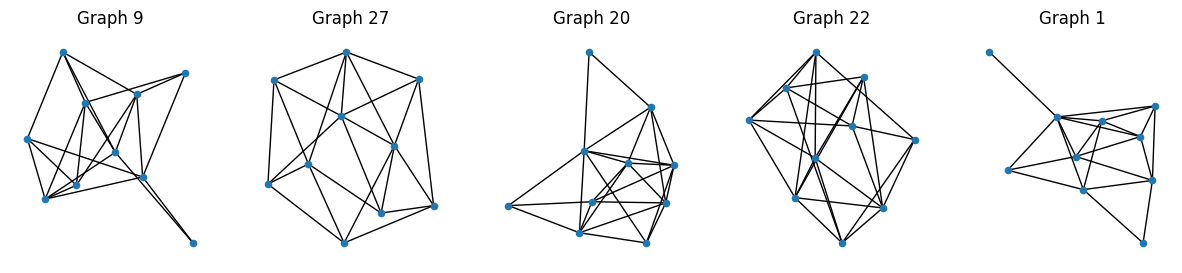

[Epoch 500/5000] D loss: 0.3253 | G loss: 2.0802 | Planar Graphs: 32/32


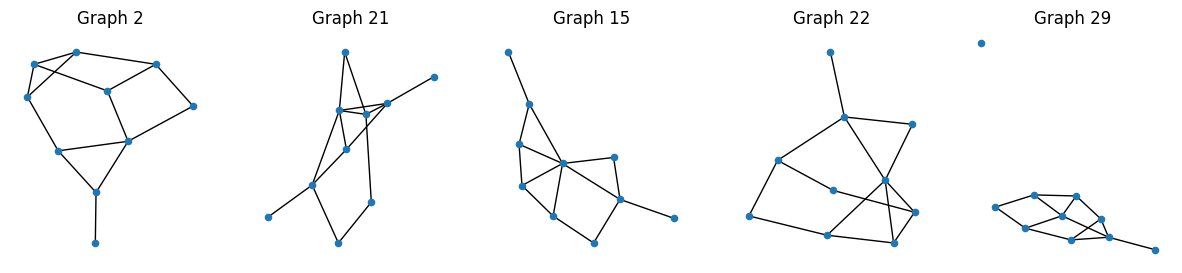

[Epoch 1000/5000] D loss: 0.3252 | G loss: 2.0871 | Planar Graphs: 31/32


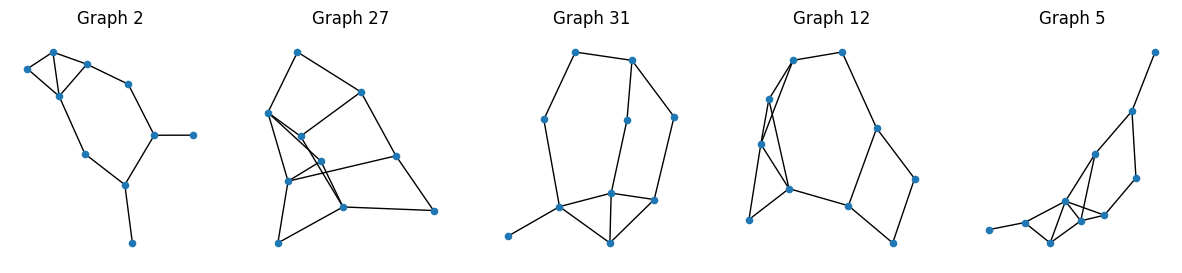

[Epoch 1500/5000] D loss: 0.3251 | G loss: 2.0902 | Planar Graphs: 27/32


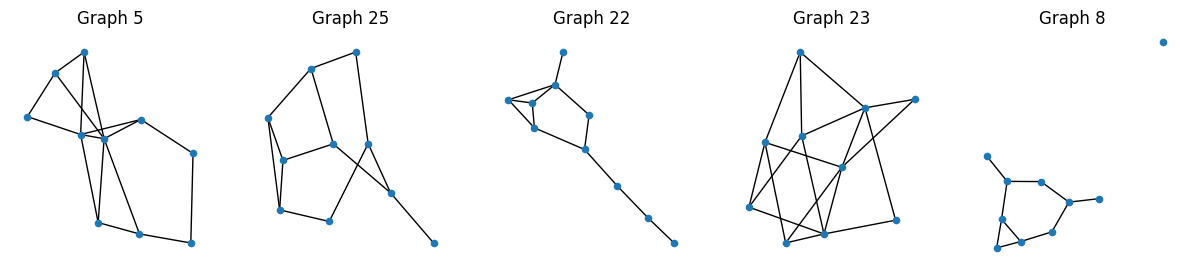

[Epoch 2000/5000] D loss: 0.3251 | G loss: 2.0805 | Planar Graphs: 27/32


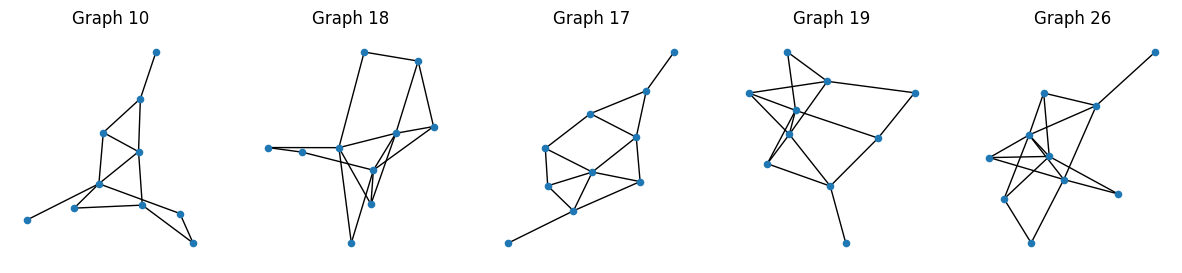

[Epoch 2500/5000] D loss: 0.3251 | G loss: 2.0810 | Planar Graphs: 26/32


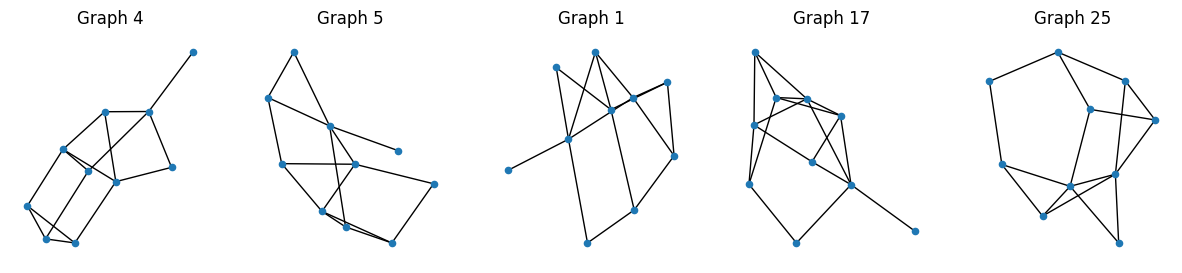

[Epoch 3000/5000] D loss: 0.3251 | G loss: 2.0828 | Planar Graphs: 30/32


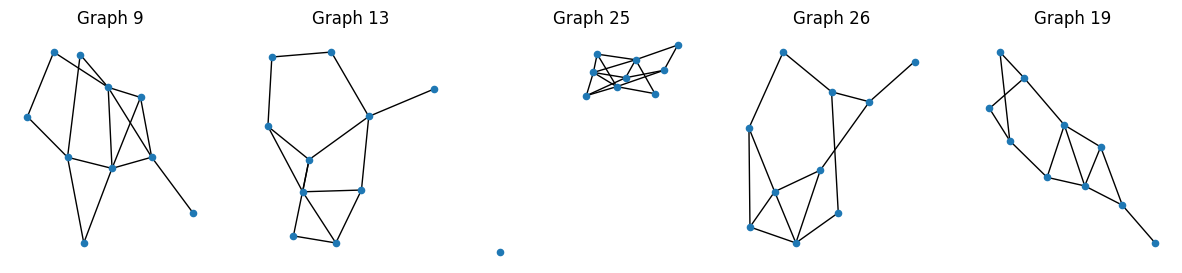

[Epoch 3500/5000] D loss: 0.3251 | G loss: 2.0833 | Planar Graphs: 29/32


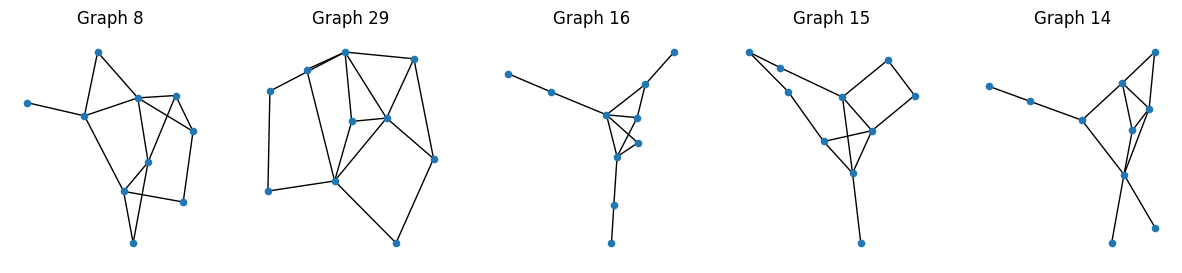

[Epoch 4000/5000] D loss: 0.3251 | G loss: 2.0785 | Planar Graphs: 28/32


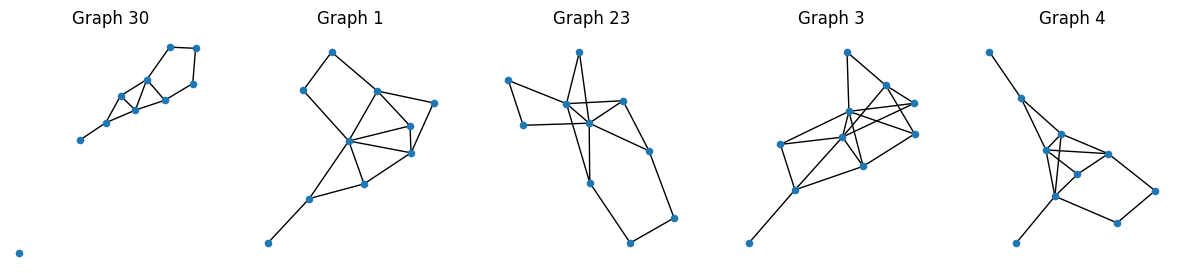

[Epoch 4500/5000] D loss: 0.3251 | G loss: 2.0827 | Planar Graphs: 28/32


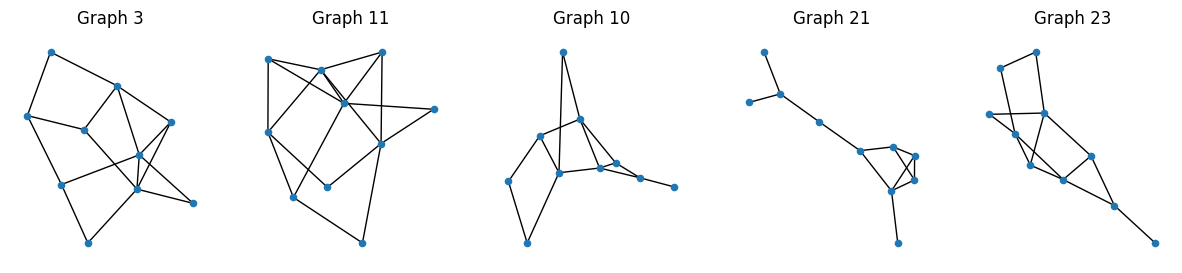

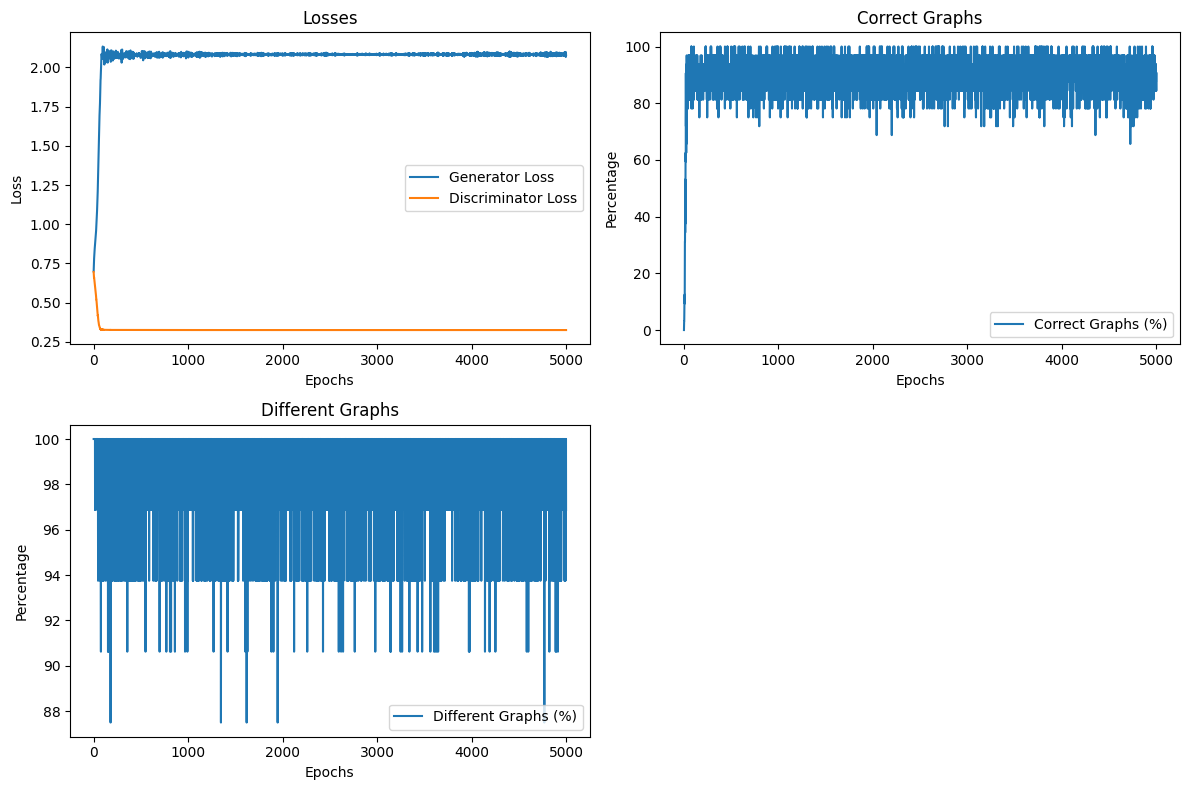

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import networkx as nx

# Paramètres
latent_dim = 100  # Dimension de l'espace latent
matrix_size = train_data.shape[1]  # Taille des matrices (n x n)

threshold = 0.5
alpha = 10  # Coefficient pour la pénalité sur K3,3 et K5

# Vérifie la présence de sous-graphes K3,3 ou K5
def contains_subgraph_k33_k5(G):
    K33 = nx.complete_bipartite_graph(3, 3)
    K5 = nx.complete_graph(5)
    # Vérification de sous-graphes isomorphes
    matcher_k33 = nx.algorithms.isomorphism.GraphMatcher(G, K33)
    matcher_k5 = nx.algorithms.isomorphism.GraphMatcher(G, K5)
    return matcher_k33.subgraph_is_isomorphic() or matcher_k5.subgraph_is_isomorphic()

# Fonction de pénalité pour le générateur
def penalty_k33_k5(fake_matrices):
    penalty = 0
    for fake_matrix in fake_matrices:
        binary_matrix = (fake_matrix > threshold).astype(int)  # Binarisation
        G = nx.from_numpy_array(binary_matrix)
        if contains_subgraph_k33_k5(G):  # Vérification des sous-graphes interdits
            penalty += 1
    return penalty

# Fonction pour calculer la densité et appliquer une pénalité si elle est trop élevée
def penalty_density(fake_matrices, density_threshold=0.5):
    penalty = 0
    for fake_matrix in fake_matrices:
        binary_matrix = (fake_matrix > threshold).astype(int)  # Binarisation
        G = nx.from_numpy_array(binary_matrix)
        density = nx.density(G)
        if density > density_threshold:  # Si la densité dépasse le seuil
            penalty += (density - density_threshold)  # Pénalité proportionnelle à l'excès
    return penalty

# Fonction pour calculer le pourcentage de graphes corrects
def calculate_correct_graphs(fake_matrices, threshold=0.5):
    correct_count = 0
    for fake_matrix in fake_matrices:
        binary_matrix = (fake_matrix > threshold).astype(int)
        G = nx.from_numpy_array(binary_matrix)
        if nx.check_planarity(G)[0] and not contains_subgraph_k33_k5(G):
            correct_count += 1
    return correct_count / len(fake_matrices) * 100

# Fonction pour calculer le pourcentage de graphes différents
def calculate_different_graphs(fake_matrices, threshold=0.5):
    unique_graphs = set()
    for fake_matrix in fake_matrices:
        binary_matrix = (fake_matrix > threshold).astype(int)
        G = nx.from_numpy_array(binary_matrix)
        unique_graphs.add(nx.to_numpy_array(G).tostring())  # Représentation unique
    return len(unique_graphs) / len(fake_matrices) * 100

# Générateur
class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, output_dim * output_dim),
            nn.Sigmoid()  # Pour produire des valeurs entre 0 et 1
        )
        self.output_dim = output_dim

    def forward(self, z):
        x = self.model(z)
        x = x.view(-1, self.output_dim, self.output_dim)
        # Symétrisation pour garantir un graphe non-orienté
        x = (x + x.transpose(1, 2)) / 2
        # Annuler les diagonales (pas de boucles)
        x = x * (1 - torch.eye(10)) # 10 nombre de noeuds
        return x

# Discriminateur
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim * input_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()  # Probabilité que la matrice soit réelle
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Aplatir la matrice
        return self.model(x)

# Initialiser les modèles
generator = Generator(latent_dim, matrix_size)
discriminator = Discriminator(matrix_size)

# Optimiseurs
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002)
scheduler_G = optim.lr_scheduler.ExponentialLR(optimizer_G, gamma=0.9)  # Réduit LR de 10% à chaque étape
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002)

# Fonction de perte
adversarial_loss = nn.BCELoss()

# Buffer pour stocker les graphes valides
memory_buffer = []
max_memory_size = 100  # Taille maximale du buffer

# Boucle d'entraînement
epochs = 5000
batch_size = 32

real_labels = torch.full((batch_size, 1), 0.9)  # Labels réels ajustés
fake_labels = torch.full((batch_size, 1), 0.1)  # Labels faux ajustés

# Initialisation des listes pour le suivi des métriques
g_losses = []
d_losses = []
correct_graph_percentages = []
different_graph_percentages = []

# Boucle d'entraînement mise à jour
for epoch in range(epochs):

    scheduler_G.step()

    # Entraîner le Discriminateur
    idx = np.random.randint(0, train_data.shape[0], batch_size)
    real_matrices = torch.tensor(train_data[idx], dtype=torch.float32)

    z = torch.randn(batch_size, latent_dim)  # Vecteur latent (bruit)
    fake_matrices = generator(z)

    optimizer_D.zero_grad()
    real_loss = adversarial_loss(discriminator(real_matrices), real_labels)
    fake_loss = adversarial_loss(discriminator(fake_matrices.detach()), fake_labels)
    d_loss = (real_loss + fake_loss) / 2
    d_loss.backward()
    optimizer_D.step()

    # Entraîner le Générateur
    optimizer_G.zero_grad()
    g_loss = adversarial_loss(discriminator(fake_matrices), real_labels)

    # Calcul des pénalités
    penalty_k33_k5_val = penalty_k33_k5(fake_matrices.detach().numpy())
    penalty_density_val = penalty_density(fake_matrices.detach().numpy(), density_threshold=0.5)

    # Poids pour chaque pénalité
    alpha_k33_k5 = 10
    alpha_density = max(1 - (epoch / epochs), 0.1) * 5  # Réduit la pénalité au fil du temps

    # Perte totale
    total_loss = (
        g_loss
        + alpha_k33_k5 * penalty_k33_k5_val / batch_size
        + alpha_density * penalty_density_val / batch_size
    )
    total_loss.backward()
    optimizer_G.step()

    # Calcul des métriques
    correct_graph_percentage = calculate_correct_graphs(fake_matrices.detach().numpy())
    different_graph_percentage = calculate_different_graphs(fake_matrices.detach().numpy())

    # Stocker les métriques
    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())
    correct_graph_percentages.append(correct_graph_percentage)
    different_graph_percentages.append(different_graph_percentage)

    # Affichage périodique
    if epoch % 500 == 0:
        planar_count = 0
        k33_k5_count = 0
        for fake_matrix in fake_matrices.detach().numpy():
            binary_matrix = (fake_matrix > threshold).astype(int)
            G = nx.from_numpy_array(binary_matrix)
            if nx.check_planarity(G)[0]:
                planar_count += 1

        print(f"[Epoch {epoch}/{epochs}] D loss: {d_loss.item():.4f} | "
              f"G loss: {g_loss.item():.4f} | Planar Graphs: {planar_count}/{batch_size}")

        # Affichage des graphes
        fig, axes = plt.subplots(1, 5, figsize=(15, 3))
        sample_indices = np.random.choice(fake_matrices.shape[0], 5, replace=False)
        for i, ax in zip(sample_indices, axes):
            binary_matrix = (fake_matrices[i].detach().numpy() > threshold).astype(int)
            G = nx.from_numpy_array(binary_matrix)
            nx.draw(G, ax=ax, node_size=20, font_size=8)
            ax.set_title(f"Graph {i}")
        plt.show()

# Tracé des métriques après l'entraînement
plt.figure(figsize=(12, 8))

# Plot des pertes
plt.subplot(2, 2, 1)
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.title("Losses")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Plot du pourcentage de graphes corrects
plt.subplot(2, 2, 2)
plt.plot(correct_graph_percentages, label="Correct Graphs (%)")
plt.title("Correct Graphs")
plt.xlabel("Epochs")
plt.ylabel("Percentage")
plt.legend()

# Plot du pourcentage de graphes différents
plt.subplot(2, 2, 3)
plt.plot(different_graph_percentages, label="Different Graphs (%)")
plt.title("Different Graphs")
plt.xlabel("Epochs")
plt.ylabel("Percentage")
plt.legend()

plt.tight_layout()
plt.show()